# Section 1
Edge Detection

In [1]:
!gdown "1VTvvWRgcyb0LjOsQzUsydXa2hKQbs2Zc"

Downloading...
From: https://drive.google.com/uc?id=1VTvvWRgcyb0LjOsQzUsydXa2hKQbs2Zc
To: /content/lab 06 noisy_image.jpg
100% 107k/107k [00:00<00:00, 12.0MB/s]


Given an image with noise, use the following three algorithms for edge detection:

1. Sobel operator

2. Canny algorithm

3. Mar-hildreth algorithm

Display the results respectively.

***(Explaination answer)***

- Q1. Which algorithm is most sensitive to noise?

- Q2. In Canny and Mar-Hildreth algorithms, after the adjusting of kernel size and standard deviation of Gaussian blur, what changes can you observe in the edge detection results? How does Gaussian smoothing affect edge detection?

- Q3. Which algorithm do you think is best for processing high noise images?  Justify your answer.




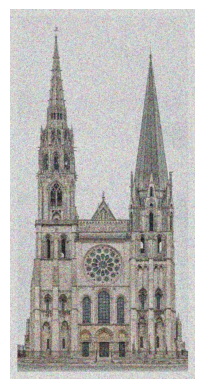

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
img= cv.imread('/content/lab 06 noisy_image.jpg')
plt.imshow(img[:,:,::-1])
plt.axis("off")
plt.show()

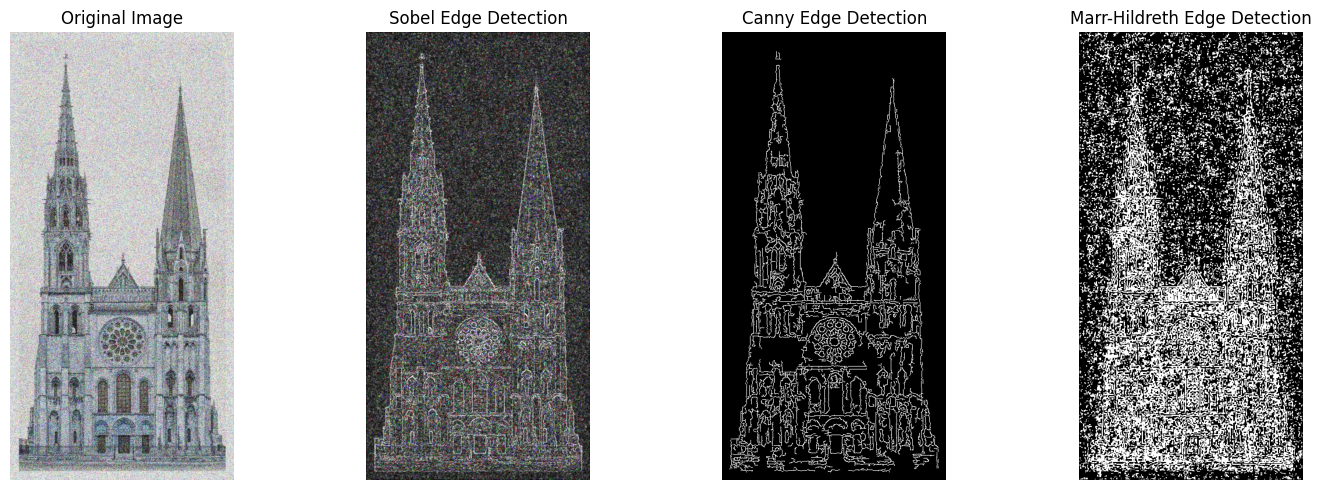

In [4]:
# Answer your code here
import numpy as np
# Compute Sobel gradient results
sobel_x = cv.Sobel(img, cv.CV_16S, 1, 0)  # Horizontal gradient (dx=1, dy=0)
sobel_y = cv.Sobel(img, cv.CV_16S, 0, 1) # Vertical gradient (dx=0, dy=1)

# Convert the gradient results to uint8 format
Scale_absX = cv.convertScaleAbs(sobel_x)   # Convert Sobel X to uint8
Scale_absY = cv.convertScaleAbs(sobel_y)

# Combine Sobel results
sobel_result = cv.addWeighted(Scale_absX, 0.5, Scale_absY, 0.5, 0)

# Compute Canny edge detection result
lowThreshold = 50 # Set the lower threshold for edge detection
highThreshold = 150  # Set the upper threshold for edge detection

# Apply Canny edge detection
filtered_img = cv.GaussianBlur(img, (5, 5), 4)
canny_result = cv.Canny(filtered_img, lowThreshold, highThreshold)

# Marr-Hildreth
blurred = cv.GaussianBlur(img, (5, 5), 1.9)

# Step 3: Compute Laplacian of the smoothed image
laplacian = cv.Laplacian(blurred, cv.CV_64F)  # Use CV_64F to capture negative values

# Step 4: Detect Zero-Crossings with Thresholding
threshold = 6  # Set a threshold for significant edges
# A threshold is used to ignore small variations (caused by noise or minor gradients) and focus only on significant changes in the Laplacian values

zero_crossings = np.zeros_like(laplacian, dtype=np.uint8)
# A new matrix is created with the same shape as the laplacian result, initialized with zeros. This matrix will store the edges

rows, cols, _ = laplacian.shape

for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        # Extract 3×3 Neighborhood
        patch = laplacian[i-1:i+2, j-1:j+2]  # 3x3 patch around the pixel
        # Check for Zero Crossing
        if (patch.min() < -threshold) and (patch.max() > threshold):  # Check zero-crossing with threshold
            zero_crossings[i, j] = 255  # If the above condition is true， mark as an edge

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Sobel Edge Detection")
plt.imshow(sobel_result, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Canny Edge Detection")
plt.imshow(canny_result, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Marr-Hildreth Edge Detection")
plt.imshow(zero_crossings, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

## Q1. Which algorithm is most sensitive to noise?

Ans. Marr-Hildreth algorithm

## Q2. In Canny and Mar-Hildreth algorithms, after the adjusting of kernel size and standard deviation of Gaussian blur, what changes can you observe in the edge detection results? How does Gaussian smoothing affect edge detection?

Ans. Modifying the kernel size and standard deviation of Gaussian Blur impacts edge detection by smoothing the image and minimizing noise. If these values are set too high, fine edges might be lost. Conversely, setting them too low preserves details but increases noise in the outcome. Gaussian Smoothing is essential for balancing noise reduction with the retention of important edges in an image.



---

การปรับขนาดเคอร์เนลและค่าเบี่ยงเบนมาตรฐานของ Gaussian Blur มีผลต่อการตรวจจับขอบโดยทำให้ภาพเรียบขึ้นและ Noiseหากตั้งค่าสูงเกินไป ขอบที่ละเอียดอ่อนอาจหายไป แต่หากตั้งค่าต่ำเกินไป จะรักษารายละเอียดไว้ได้แต่เพิ่ม Noise ในผลลัพธ์ Gaussian Smoothing จึงมีบทบาทสำคัญในการสร้างสมดุลระหว่างการลด Noise และการรักษาขอบที่สำคัญในภาพ

## Q3. Which algorithm do you think is best for processing high noise images? Justify your answer.

Ans. The Canny algorithm is considered the best because, as shown in the image, it remains unaffected by noise. However, it may not produce edges as sharply defined as the Sobel algorithm.



---

Canny algorithm ถือว่าดีที่สุดเพราะจากภาพจะเห็นว่าไม่ได้รับผลกระทบจาก noise เลย แม้ว่าอาจจะสร้างขอบได้ไม่คมชัดเท่า Sobel algorithm

# Section 2


In [5]:
!gdown "1QAG2i9RVuArct8JseVD0Oq8Hsxz3spRd"

Downloading...
From: https://drive.google.com/uc?id=1QAG2i9RVuArct8JseVD0Oq8Hsxz3spRd
To: /content/lab 06 church.jpg
100% 209k/209k [00:00<00:00, 86.6MB/s]


Given an image, use the following three algorithms for edge detection:

1. Sobel operator

2. Canny algorithm

3. Mar-hildreth algorithm

Display the results respectively.

***(Explaination answer)***

- Q1. Which algorithm produces the most detailed edges?
- Q2. Which algorithm provides the most accurate and continuous edges? Justify your reasoning.
- Q3. Based on your observations, which algorithm do you think is the best for general image processing tasks?




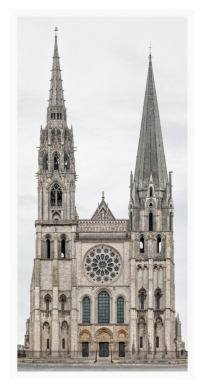

In [7]:
img2 = cv.imread('/content/lab 06 church.jpg')
plt.imshow(img[:,:,::-1])
plt.axis("off")
plt.show()

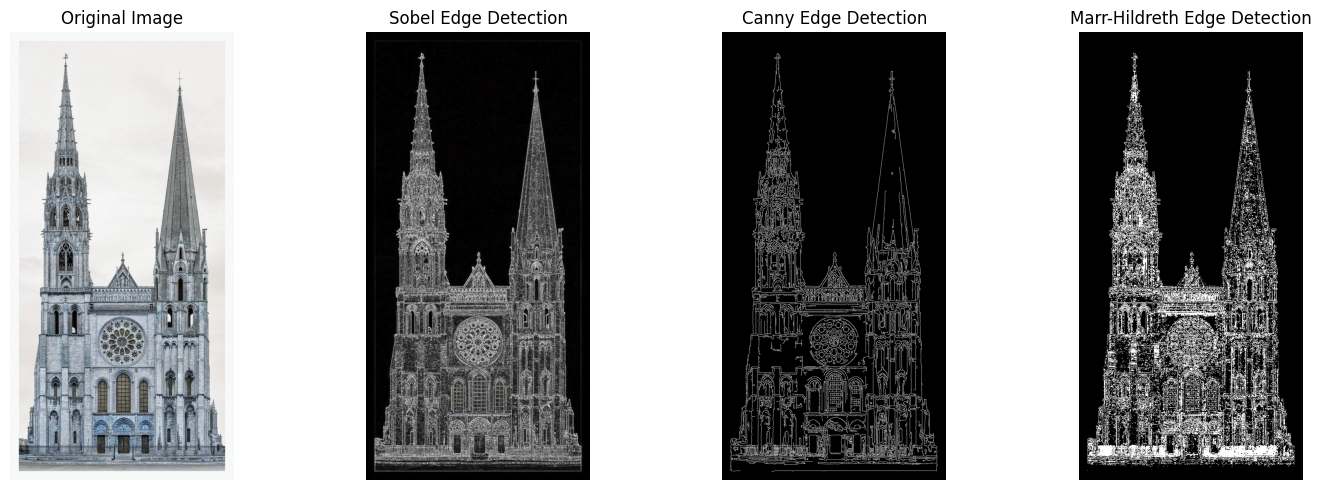

In [8]:
# Answer your code here

# Compute Sobel gradient results
sobel_x = cv.Sobel(img2, cv.CV_16S, 1, 0)  # Horizontal gradient (dx=1, dy=0)
sobel_y = cv.Sobel(img2, cv.CV_16S, 0, 1) # Vertical gradient (dx=0, dy=1)

# Convert the gradient results to uint8 format
Scale_absX = cv.convertScaleAbs(sobel_x)   # Convert Sobel X to uint8
Scale_absY = cv.convertScaleAbs(sobel_y)

# Combine Sobel results
sobel_result = cv.addWeighted(Scale_absX, 0.5, Scale_absY, 0.5, 0)

# Compute Canny edge detection result
lowThreshold = 50 # Set the lower threshold for edge detection
highThreshold = 150  # Set the upper threshold for edge detection

# Apply Canny edge detection
filtered_img = cv.GaussianBlur(img2, (5, 5), 4)
canny_result = cv.Canny(filtered_img, lowThreshold, highThreshold)

# Marr-Hildreth
blurred = cv.GaussianBlur(img2, (5, 5), 1.9)

# Step 3: Compute Laplacian of the smoothed image
laplacian = cv.Laplacian(blurred, cv.CV_64F)  # Use CV_64F to capture negative values

# Step 4: Detect Zero-Crossings with Thresholding
threshold = 6  # Set a threshold for significant edges
# A threshold is used to ignore small variations (caused by noise or minor gradients) and focus only on significant changes in the Laplacian values

zero_crossings = np.zeros_like(laplacian, dtype=np.uint8)
# A new matrix is created with the same shape as the laplacian result, initialized with zeros. This matrix will store the edges

rows, cols, _ = laplacian.shape

for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        # Extract 3×3 Neighborhood
        patch = laplacian[i-1:i+2, j-1:j+2]  # 3x3 patch around the pixel
        # Check for Zero Crossing
        if (patch.min() < -threshold) and (patch.max() > threshold):  # Check zero-crossing with threshold
            zero_crossings[i, j] = 255  # If the above condition is true， mark as an edge

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(img2, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Sobel Edge Detection")
plt.imshow(sobel_result, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Canny Edge Detection")
plt.imshow(canny_result, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Marr-Hildreth Edge Detection")
plt.imshow(zero_crossings, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

## Q1. Which algorithm produces the most detailed edges?

Ans. Sobel algorithm

## Q2. Which algorithm provides the most accurate and continuous edges? Justify your reasoning.

Ans. The Sobel algorithm is the most effective, as it captures the intricate details of the castle's edges.



---

 Sobel algorithm ดีที่สุด เพราะสามารถเก็บรายละเอียดของขอบปราสาทได้อย่างแม่นยำ

## Q3. Based on your observations, which algorithm do you think is the best for general image processing tasks?

Ans. Sobel algorithm, as it effectively balances edge detection and noise reduction, making it suitable for a wide range of image processing applications.



---

Sobel algorithm เพราะมีความสมดุลระหว่างการตรวจจับขอบและการลดสัญญาณรบกวนได้อย่างมีประสิทธิภาพ ทำให้เหมาะสำหรับการประมวลผลภาพในงานต่าง ๆ มีความสามารถในการเน้นขอบที่สำคัญพร้อมกับรักษาความคมชัดและรายละเอียด



# Section 3

**Lane Detection**

Lane detection is one of the basic concepts when trying to understand how self-driving cars work.Hough transform can help to detect straight lines in the region of interest.

**Q1 : In this section you will deal with 2 image of lane data and try to show result of lane detection.**

**Tools**
* Edge Detection Ex. Canny.
* Line Detection Ex. Hough Transform Technique.
* Other tools you can also use to apply in your code.

> This is 2 image data for using in your code of this section.



In [9]:
# Road1 gray-scale image (name:lane.jpg)
!gdown "1Y4ihYnHmxBKSK5SZKFrdKLW_-hGGSvFZ"

Downloading...
From: https://drive.google.com/uc?id=1Y4ihYnHmxBKSK5SZKFrdKLW_-hGGSvFZ
To: /content/lane.jpg
100% 35.2k/35.2k [00:00<00:00, 34.0MB/s]


In [10]:
# Road2 color image (name:lane2.jpg)
!gdown "1BWa86A6oSJTXOFPiTzb0g2KvCbBcqeuF"

Downloading...
From: https://drive.google.com/uc?id=1BWa86A6oSJTXOFPiTzb0g2KvCbBcqeuF
To: /content/lane2.jpg
100% 776k/776k [00:00<00:00, 107MB/s]


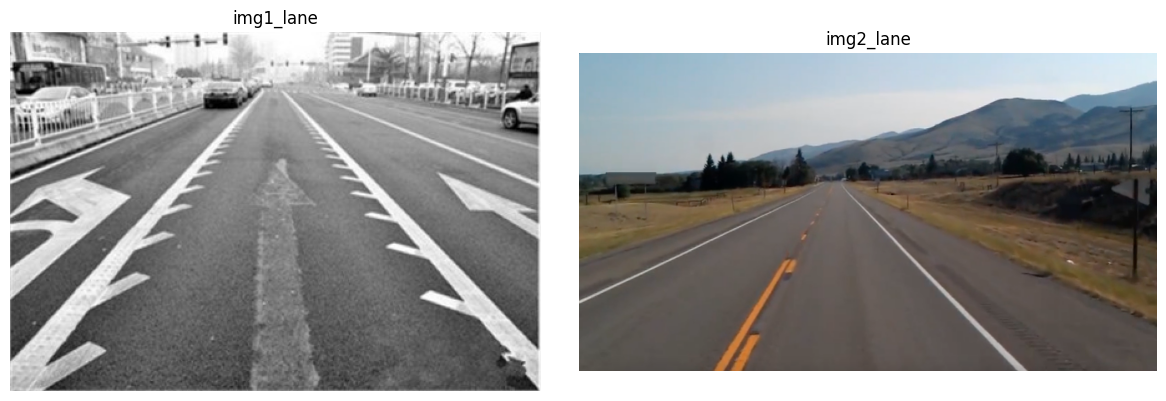

In [11]:
img1_lane= cv.imread('/content/lane.jpg')
img2_lane= cv.imread('/content/lane2.jpg')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1_lane[:,:,::-1], cmap='brg', vmin=0, vmax=1)
plt.title('img1_lane')
plt.axis('off')

# Step 9: results of dest diliated
plt.subplot(1, 2, 2)
plt.imshow(img2_lane[:,:,::-1], cmap='brg', vmin=0, vmax=1)
plt.title('img2_lane')
plt.axis('off')

plt.tight_layout()
plt.show()


## Marr-Hildreth

In [ ]:
#Add your code here!


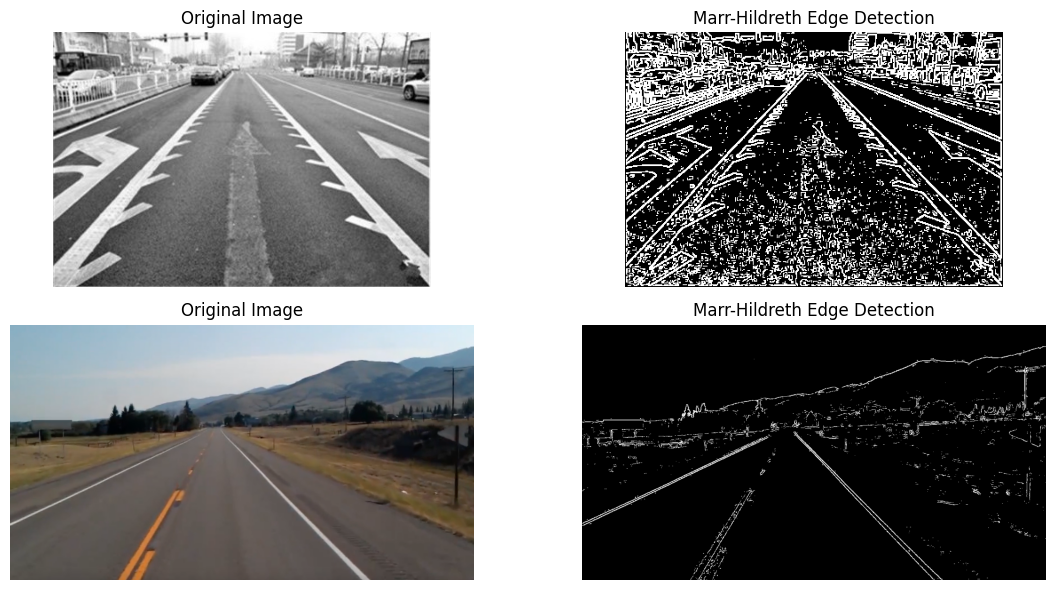

In [14]:
# Apply Gaussian filter (smoothing)
blurred_1 = cv.GaussianBlur(img1_lane, (5, 5), 1.2)
blurred_2 = cv.GaussianBlur(img2_lane, (5, 5), 1.2)

# Compute Laplacian of the smoothed image
laplacian_1 = cv.Laplacian(blurred_1, cv.CV_64F)  # Use CV_64F to capture negative values
laplacian_2 = cv.Laplacian(blurred_2, cv.CV_64F)

# Detect Zero-Crossings with Thresholding
threshold = 3  # Set a threshold for significant edges

zero_crossings_1 = np.zeros_like(laplacian_1, dtype=np.uint8)

rows, cols, _ = laplacian_1.shape

for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        # Extract 3×3 Neighborhood
        patch = laplacian_1[i-1:i+2, j-1:j+2]  # 3x3 patch around the pixel
        # Check for Zero Crossing
        if (patch.min() < -threshold) and (patch.max() > threshold):  # Check zero-crossing with threshold
            zero_crossings_1[i, j] = 255  # If the above condition is true， mark as an edge

zero_crossings_2 = np.zeros_like(laplacian_2, dtype=np.uint8)

rows2, cols2, _ = laplacian_2.shape

for i in range(1, rows2 - 1):
    for j in range(1, cols2 - 1):
        # Extract 3×3 Neighborhood
        patch = laplacian_2[i-1:i+2, j-1:j+2]  # 3x3 patch around the pixel
        # Check for Zero Crossing
        if (patch.min() < -threshold) and (patch.max() > threshold):  # Check zero-crossing with threshold
            zero_crossings_2[i, j] = 255  # If the above condition is true， mark as an edge

# Display the original image and Marr-Hildreth result
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(img1_lane, cmap='gray')
plt.axis("off")

# Marr-Hildreth Edge Detection
plt.subplot(2, 2, 2)
plt.title("Marr-Hildreth Edge Detection")
plt.imshow(zero_crossings_1, cmap='gray')
plt.axis("off")

# Original Image
plt.subplot(2, 2, 3)
plt.title("Original Image")
plt.imshow(img2_lane)
plt.axis("off")

# Marr-Hildreth Edge Detection
plt.subplot(2, 2, 4)
plt.title("Marr-Hildreth Edge Detection")
plt.imshow(zero_crossings_2, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

## Canny Algorithm

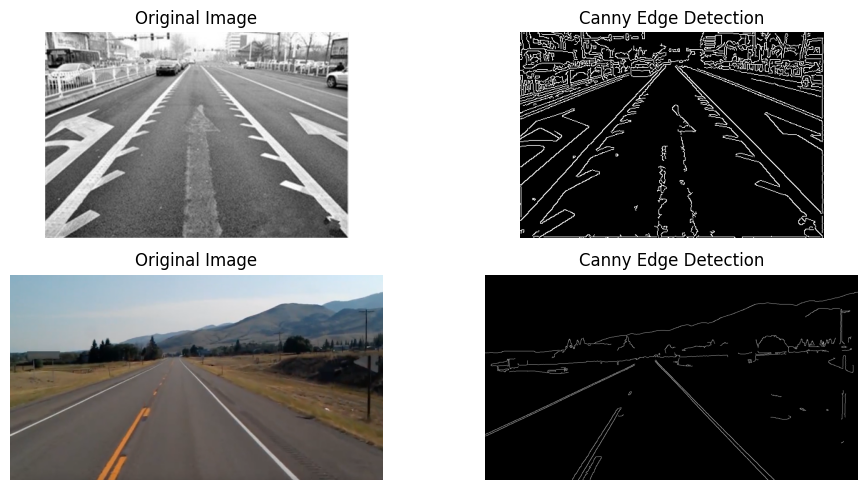

In [12]:
# Perform Canny edge detection

img2_lane = img2_lane[:,:,::-1]

lowThreshold = 50 # Set the lower threshold for edge detection
highThreshold = 150  # Set the upper threshold for edge detection

# Apply Canny edge detection
filtered_img_1 = cv.GaussianBlur(img1_lane, (5, 5), 0.8)
canny_result_1 = cv.Canny(filtered_img_1, lowThreshold, highThreshold)

filtered_img_2 = cv.GaussianBlur(img2_lane, (5, 5), 0.8)
canny_result_2 = cv.Canny(filtered_img_2, lowThreshold, highThreshold)
#  Default is 3x3 and Sobel is used for gradient computation


plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(img1_lane, cmap='gray')
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Canny Edge Detection")
plt.imshow(canny_result_1, cmap='gray')
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Original Image")
plt.imshow(img2_lane, cmap='brg')
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Canny Edge Detection")
plt.imshow(canny_result_2, cmap='gray')
plt.axis("off")


plt.tight_layout()
plt.show()

## Hough Transform

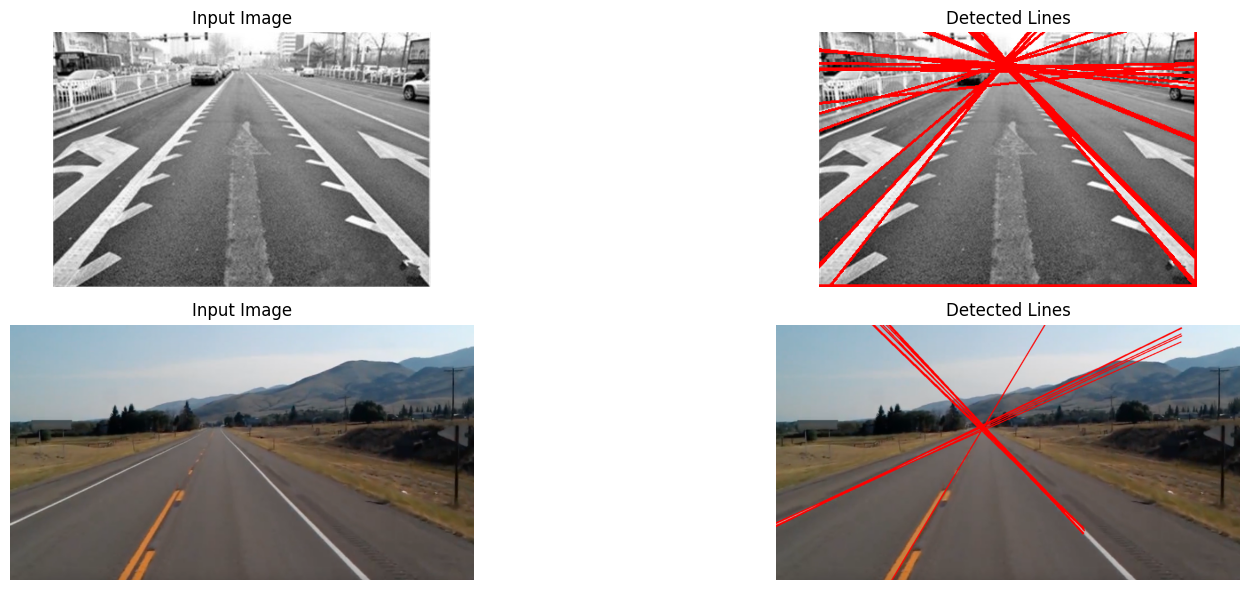

In [13]:
# Preprocessing (Edge Detection)
edges_1 = cv.Canny(img1_lane, threshold1=225, threshold2=200, apertureSize=3)
edges_2 = cv.Canny(img2_lane, threshold1=225, threshold2=200, apertureSize=3)

# Hough Transform for Line Detection
lines_1 = cv.HoughLines(edges_1, rho=1, theta=np.pi/180, threshold=120)
lines_2 = cv.HoughLines(edges_2, rho=1, theta=np.pi/180, threshold=120)

# Draw the detected lines on the original image
output_image_1 = img1_lane.copy()

if lines_1 is not None:
    for line in lines_1:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv.line(output_image_1, (x1, y1), (x2, y2), (0, 0, 255), 2)

output_image_2 = img2_lane[:,:,::-1].copy()

if lines_2 is not None:
    for line in lines_2:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv.line(output_image_2, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Visualization
plt.figure(figsize=(18, 6))
plt.subplot(2, 2, 1)
plt.title("Input Image")
plt.imshow(img1_lane, cmap='gray')
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Detected Lines")
plt.imshow(cv.cvtColor(output_image_1, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Input Image")
plt.imshow(img2_lane)
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Detected Lines")
plt.imshow(cv.cvtColor(output_image_2, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()

## **Q2 : How are these two images from the lane dataset obstacles for you when implementing the code to detect lane results?**

***(Explaination answer)***

Ans. Based on the applied methods, the Canny algorithm delivered the most precise edge detection, effectively distinguishing the important features without excessive noise. On the other hand, the Marr-Hildreth algorithm struggled, as it picked up unnecessary edges on the road surface, leading to a cluttered and noisy result. The Hough Transform faced challenges with thresholding; a low threshold caused too many lines to be detected, complicating the process of accurately identifying the main edges within the image.



---

จากวิธีที่ได้ลองใช้ พบว่า Canny algorithm สามารถตรวจจับขอบได้อย่างแม่นยำที่สุด โดยแยกรายละเอียดสำคัญได้ดีโดยไม่เกิด noise มากเกินไป ในทางกลับกัน Marr-Hildreth algorithm ยังไม่สามารถทำงานได้ดีนัก เนื่องจากตรวจจับขอบที่ไม่จำเป็นบนพื้นถนน ส่งผลให้ภาพดูรกและมี noise ส่วนการทำ Hough Transform พบปัญหาในการตั้งค่า Threshold หากตั้งค่าต่ำเกินไป จะทำให้ตรวจจับเส้นมากเกินไป จนยากที่จะระบุขอบหลักในภาพได้อย่างถูกต้อง